In [5]:
import tifffile
import numpy as np
from cellpose import models
import matplotlib.pyplot as plt
from src.io import load_stack

(4, 6323, 6344) uint16 8131
(4, 6323, 6344) uint16 8131


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


Cells found: 15


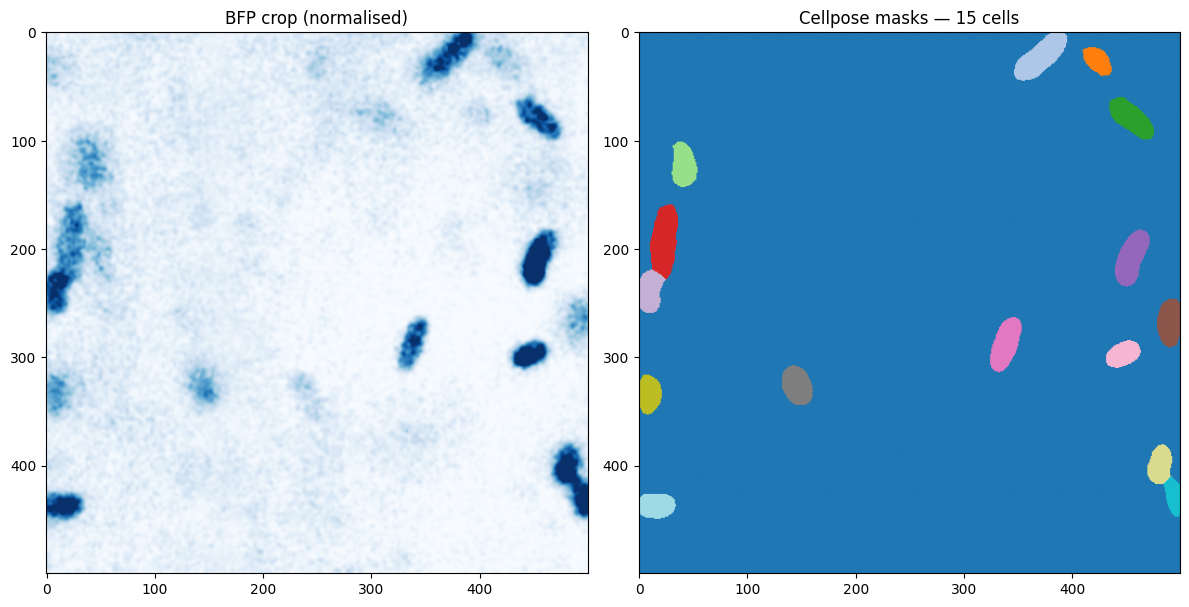

In [6]:
stack = load_stack('/Users/alicehong/cellpose-biosensor/data/raw/16bit/Scene-01-20260416-C3M2_Tcol_1-A01Export-01_c1-4_stack.tif')
print(stack.shape, stack.dtype, stack.max())
## Expected: (4, 6323, 6344) uint16 8131

# Load your stack
stack = tifffile.imread('/Users/alicehong/cellpose-biosensor/data/raw/16bit/Scene-01-20260416-C3M2_Tcol_1-A01Export-01_c1-4_stack.tif')
print(stack.shape, stack.dtype, stack.max())
# Expected: (4, 6323, 6344) uint16

# Pull BFP channel and take a small crop
bfp = stack[0]
crop = bfp[1800:2300, 2400:2900].astype(float)
crop_norm = np.clip((crop - np.percentile(crop, 1)) / 
                    (np.percentile(crop, 99) - np.percentile(crop, 1)), 0, 1)

# Run cpsam on the crop
model = models.CellposeModel(gpu=True)
masks, flows, styles = model.eval(crop_norm, diameter=None, 
                                   channels=[0,0], normalize=False)
print(f'Cells found: {masks.max()}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(crop_norm, cmap='Blues')
axes[0].set_title('BFP crop (normalised)')
axes[1].imshow(masks, cmap='tab20')
axes[1].set_title(f'Cellpose masks — {masks.max()} cells')
plt.tight_layout()
plt.show()

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


Cells detected: 15


FileNotFoundError: [Errno 2] No such file or directory: '/Users/alicehong/figures/qc/baseline_cpsam.png'

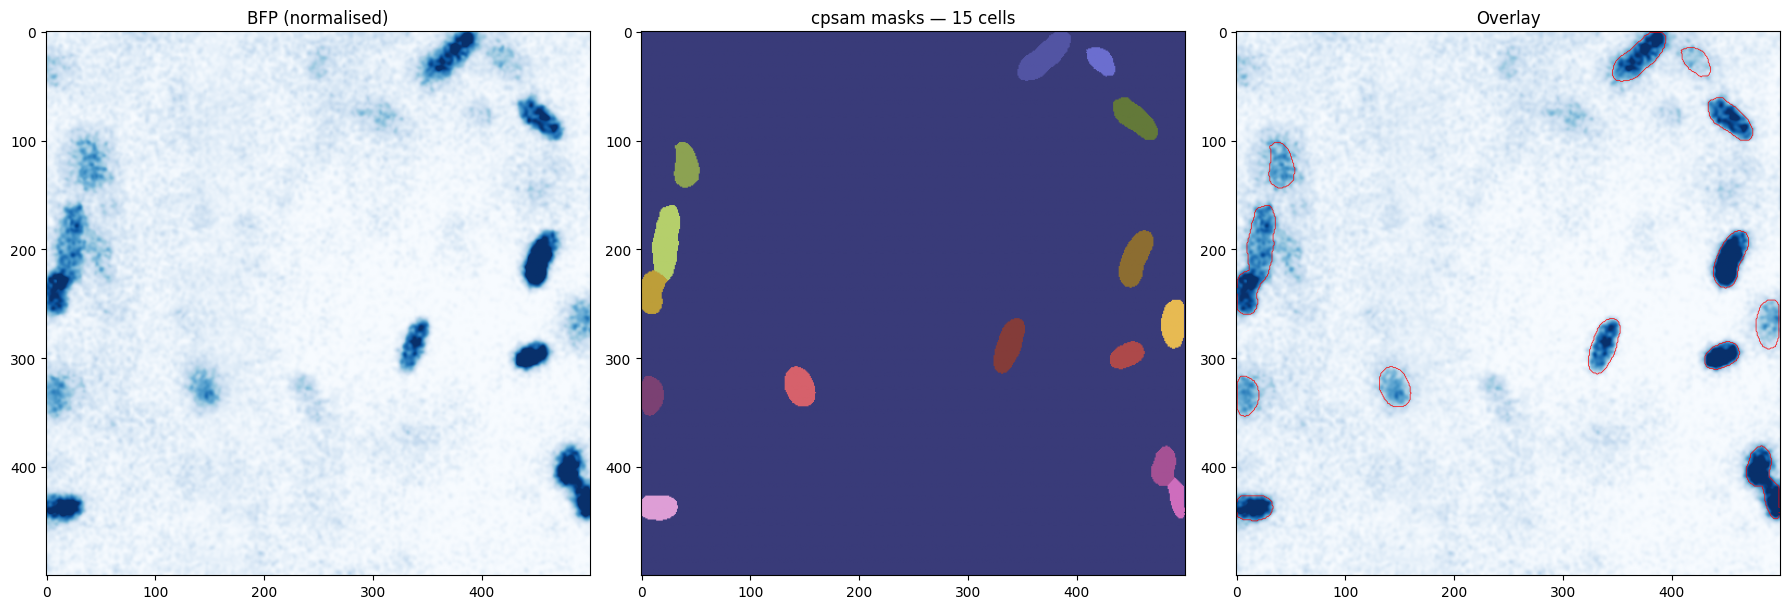

In [2]:
import tifffile
import numpy as np
from cellpose import models
import matplotlib.pyplot as plt
from src.io import load_stack, tile_image
from src.preprocess import normalize_for_segmentation

# Load and pull BFP channel
stack = load_stack('/Users/alicehong/cellpose-biosensor/data/raw/16bit/Scene-01-20260416-C3M2_Tcol_1-A01Export-01_c1-4_stack.tif')
bfp = stack[0]

# Take a crop from a bacteria-dense region
#crop = bfp[6000:6512, 3300:3812]

crop = bfp[1800:2300, 2400:2900]


crop_norm = normalize_for_segmentation(crop)

# Run baseline cpsam — no fine-tuning yet
model = models.CellposeModel(gpu=True)
masks, flows, styles = model.eval(
    crop_norm,
    diameter=None,
    channels=[0, 0],
    normalize=False
)

print(f'Cells detected: {masks.max()}')

# Visualise side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(crop_norm, cmap='Blues')
axes[0].set_title('BFP (normalised)')
axes[1].imshow(masks, cmap='tab20b')
axes[1].set_title(f'cpsam masks — {masks.max()} cells')
# Overlay
axes[2].imshow(crop_norm, cmap='Blues')
axes[2].contour(masks > 0, colors='red', linewidths=0.5)
axes[2].set_title('Overlay')
plt.tight_layout()
plt.savefig('/Users/alicehong/figures/qc/baseline_cpsam.png', dpi=150)
plt.show()